In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/w-h-dataset/SOCR-HeightWeight.csv')
df.head()
# df.colomns=['index','height','weight']

/kaggle/input/datasets/faizanhaider01/w-h-dataset/SOCR-HeightWeight.csv
/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [14]:
df.shape

(25000, 3)

In [15]:
df.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           25000 non-null  int64  
 1   Height(Inches)  25000 non-null  float64
 2   Weight(Pounds)  25000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 586.1 KB


<Axes: xlabel='Height(Inches)', ylabel='Density'>

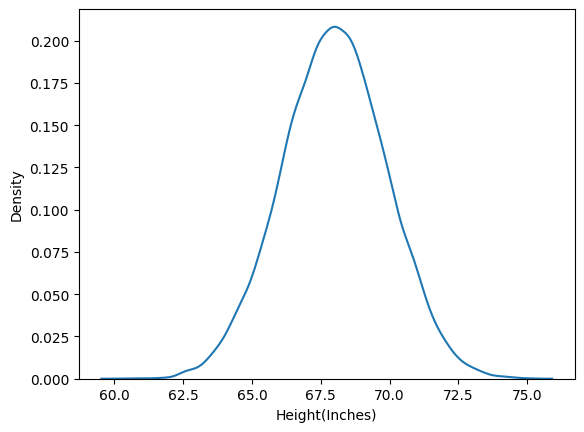

In [20]:
sns.kdeplot(df['Height(Inches)'])

<Axes: xlabel='Weight(Pounds)', ylabel='Density'>

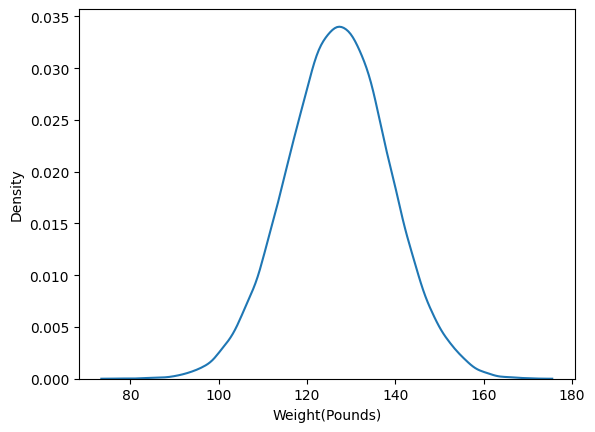

In [21]:
sns.kdeplot(df['Weight(Pounds)'])

<Axes: xlabel='Weight(Pounds)', ylabel='Height(Inches)'>

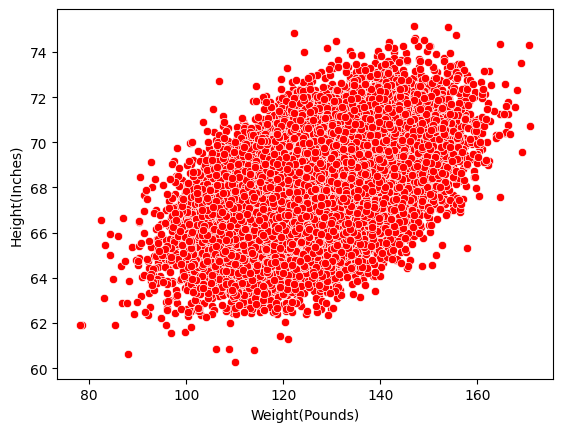

In [26]:

sns.scatterplot(y=df['Height(Inches)'],x=df['Weight(Pounds)'],color='RED')

In [27]:
X = df[['Height(Inches)']]
y = df['Weight(Pounds)']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Index', axis=1),
    df['Index'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((17500, 2), (7500, 2))

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit only on training data
scaler.fit(X_train)

# Transform
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [39]:
np.round(X_train.describe(), 1)

,Height(Inches),Weight(Pounds)
count,17500.0,17500.0
mean,68.0,127.1
std,1.9,11.6
min,60.3,78.0
25%,66.7,119.3
50%,68.0,127.2
75%,69.3,134.9
max,74.8,170.5


In [40]:
np.round(X_train_scaled.describe(), 1)

,Height(Inches),Weight(Pounds)
count,17500.0,17500.0
mean,0.5,0.5
std,0.1,0.1
min,0.0,0.0
25%,0.4,0.4
50%,0.5,0.5
75%,0.6,0.6
max,1.0,1.0


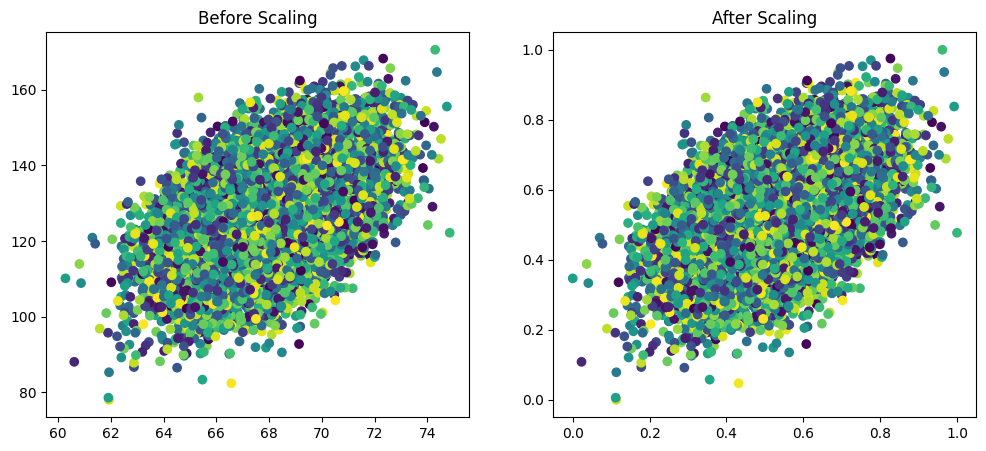

In [44]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Height(Inches)'],X_train['Weight(Pounds)'], c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled['Height(Inches)'],X_train_scaled['Weight(Pounds)'], c=y_train)
ax2.set_title("After Scaling")

plt.show()

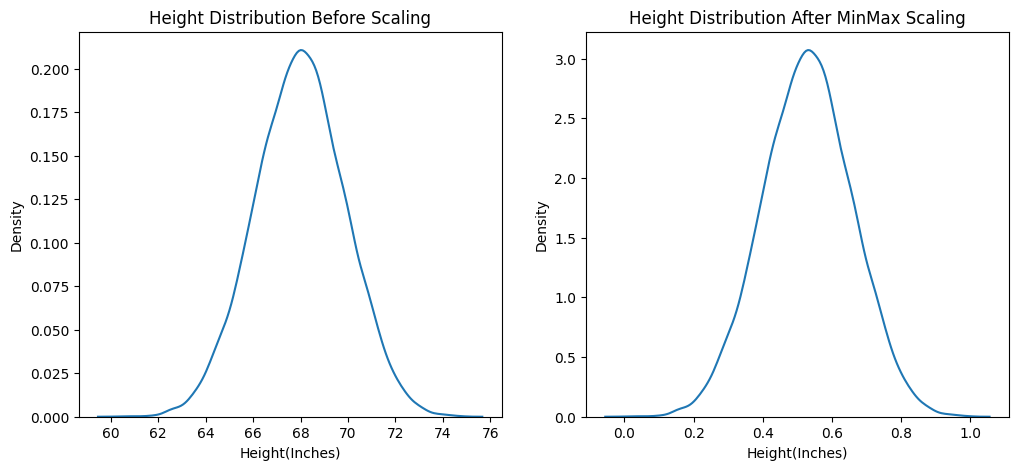

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Height Distribution Before Scaling')
sns.kdeplot(X_train['Height(Inches)'], ax=ax1)

# after scaling
ax2.set_title('Height Distribution After MinMax Scaling')
sns.kdeplot(X_train_scaled['Height(Inches)'], ax=ax2)

plt.show()